# Storm loads on fixed-tilt, ground-mounted solar panel


We treat the module as a **flat plate** in a horizontal wind and ask:
at what tilt angle are the wind loads smallest? (This is the "stow" question
every tracker controller has to answer when a storm approaches.)

Work flow:
1. Pick a **design wind speed** (50-year return period) and bring it to the panel height with a wind profile.
2. Use **simple flat-plate lift/drag curves** vs angle of attack.
3. Sweep the **tilt angle** and compute drag, vertical (lift/uplift) force, resultant force, and base overturning moment; find the **optimum stow angle**.



# Students
Change the numbers in the "INPUTS" cells and re-run. 

------------------------------------

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/miguel/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/miguel/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 566, in _log_error
    f.result()
  File "/Users/miguel/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/miguel/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/Users/miguel/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 668, in get
    value = self._validate(obj, default)
  File "/Us

In [2]:
RHO_AIR = 1.20            # air density [kg/m^3]


## 1. Design wind speed
The annual maximum wind speed at a site is often modelled with a **Gumbel**
(Type-I extreme value) distribution:
$$F(U)=\exp\!\left(-\exp\!\left(-\frac{U-\mu}{\beta}\right)\right)$$

A return period $T$ (years) corresponds to an annual exceedance probability
$p = 1/T$, so the design speed is

$$U_T=\mu-\beta\,\ln\!\left(-\ln\!\left(1-\tfrac{1}{T}\right)\right).$$

You can (a) give the Gumbel parameters directly, or (b) fit them from a record of
annual maxima.

In [3]:
def design_wind_speed_gumbel(mu, beta, return_period=50.0):
    return mu - beta * np.log(-np.log(1.0 - 1.0 / return_period))

def fit_gumbel_from_annual_maxima(annual_maxima):
    x = np.asarray(annual_maxima, float)
    beta = x.std(ddof=1) * np.sqrt(6.0) / np.pi
    mu = x.mean() - 0.5772156649 * beta
    return mu, beta



In [4]:
# -------- INPUTS: choose ONE way to set the design speed -------------
# Example annual-maxima record (10-min mean at the 10 m met mast), m/s:
annual_maxima = [22, 25, 19, 28, 31, 24, 27, 35, 21, 26, 29, 33, 23, 30, 38]
mu, beta = fit_gumbel_from_annual_maxima(annual_maxima)

U10_50yr = design_wind_speed_gumbel(mu, beta, return_period=50.0)   # 10-min mean @ 10 m

# Reference height at which the design speed above is defined:
Z_REF = 10.0        # [m]  standard meteorological height
U_REF = U10_50yr    # [m/s] 10-min mean design speed at Z_REF

print("Gumbel fit:  mu = %.2f m/s,  beta = %.2f m/s" % (mu, beta))
print("Design 10-min mean wind speed (50-yr) at %.0f m: %.1f m/s" % (Z_REF, U10_50yr))
print("Reference wind speed at %.0f m: %.1f m/s" % (Z_REF, U_REF))

Gumbel fit:  mu = 24.98 m/s,  beta = 4.19 m/s
Design 10-min mean wind speed (50-yr) at 10 m: 41.3 m/s
Reference wind speed at 10 m: 41.3 m/s


## 2. Environmental conditions for design

**Log law:**  $$U(z)=U_{ref}\,\dfrac{\ln(z/z_0)}{\ln(z_{ref}/z_0)}$$
**Power law:** $$U(z)=U_{ref}\,\left(z/z_{ref}\right)^{\alpha}$$
**Uniform:**  $$U(z)=U_{ref}$$ 

In [5]:

def U_wind_speed(z, u_ref, z_ref, model="power", z0=0.03, alpha=0.14):
    z = np.asarray(z, float)
    if model == "log":
        return u_ref * np.log(z / z0) / np.log(z_ref / z0)
    if model == "power":
        return u_ref * (z / z_ref) ** alpha
    if model == "uniform":
        return np.full_like(z, u_ref, dtype=float)
    raise ValueError("model must be 'log', 'power' or 'uniform'")

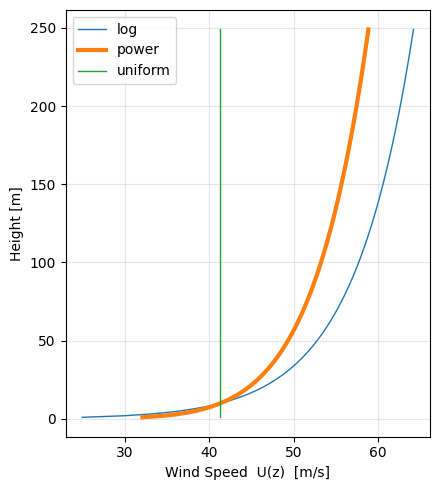

In [6]:
# -------- INPUTS: profile choice --------
PROFILE_MODEL = "power"     # "log" | "power" | "uniform"
Z0    = 0.03                # roughness length (used by log law)
ALPHA = 0.11               # shear exponent   (used by power law)

# Quick look at the profile
z_plot = np.arange(1, 250, 1)
plt.figure(figsize=(4.5, 5))
for m in ("log", "power", "uniform"):
    lw=3 if m==PROFILE_MODEL else 1
    plt.plot(U_wind_speed(z_plot, U_REF, Z_REF, m, Z0, ALPHA), z_plot, label=m, linewidth=lw)
plt.xlabel("Wind Speed  U(z)  [m/s]"); 
plt.ylabel("Height [m]")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); 
plt.show()
plt.close()

## 3. Load calculations

A sharp-edged flat plate does *not* behave like a streamlined airfoil. Three
regimes matter, and the model blends them with a single **separation
function** $\sigma(\alpha)\in[0,1]$:

**(a) Attached flow (small $\alpha$).** Thin-plate potential flow gives a steep
lift slope, $C_{l}\approx 2\pi\sin\alpha\cos\alpha$, with almost no pressure
drag. This only survives up to a low stall angle because a sharp leading edge
separates early.

**(b) Separation / stall.** Around $\alpha_{sep}\approx10^\circ$ the leading-edge
flow detaches. We model the *fraction of separated flow* with a smooth switch
$$\sigma(\alpha)=\frac{1}{1+\exp\!\big[-(|\alpha|-\alpha_{sep})/\Delta\big]}.$$

**(c) Fully separated bluff plate (large $\alpha$).** The wake is fully
detached and the resultant acts essentially **normal to the plate** with
$C_{N}=C_{N,\max}\sin\alpha$, i.e. $C_l=C_{N}\cos\alpha$, $C_d=C_{N}\sin\alpha$.
At $\alpha=90^\circ$ this gives the bluff-plate drag $C_d=C_{N,\max}$.

Blended coefficients:
$$C_l=(1-\sigma)\,C_{l,\text{att}}+\sigma\,C_{l,\text{sep}},\qquad
   C_d=(1-\sigma)\,C_{d,\text{att}}+\sigma\,C_{d,\text{sep}}.$$


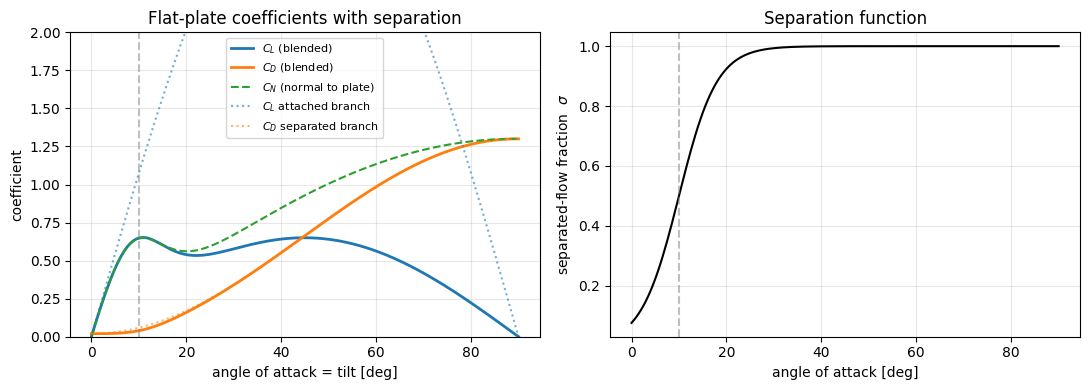

In [7]:
CN_MAX        = 1.3     # bluff-plate normal-force coeff at 90 deg
                        #   2-D plate ~1.9-2.0; finite/low-aspect panel ~1.2-1.4
ALPHA_SEP_DEG = 10.0    # separation-onset (stall) angle for a sharp plate
SEP_WIDTH_DEG = 4.0     # how abruptly the flow separates
CL_SLOPE      = 2*np.pi # attached lift-curve slope [per rad]
CD_FRIC       = 0.02    # skin-friction / baseline drag
 
def flat_plate_coeffs(alpha_deg, cn_max=CN_MAX, alpha_sep_deg=ALPHA_SEP_DEG,
                      sep_width_deg=SEP_WIDTH_DEG, cl_slope=CL_SLOPE, cd_fric=CD_FRIC,
                      return_parts=False):
    """Flat-plate coefficients including leading-edge separation.
 
    Returns (Cl, Cd, Cn) in wind axes (Cl vertical, Cd along wind) plus the
    plate-normal coefficient Cn. Valid for -90 deg <= alpha <= 90 deg.
    With return_parts=True also returns the attached/separated branches and
    the separation function sigma, for plotting.
    """
    a_deg = np.asarray(alpha_deg, float)
    sgn = np.sign(a_deg)
    ad = np.abs(a_deg)
    a = np.radians(ad)
 
    # separation function: 0 = fully attached, 1 = fully separated
    sigma = 1.0 / (1.0 + np.exp(-(ad - alpha_sep_deg) / sep_width_deg))
 
    # (a) attached, potential-flow branch (bounded thin-plate form)
    cl_att = cl_slope * np.sin(a) * np.cos(a)
    cd_att = cd_fric * np.ones_like(a)
 
    # (c) fully separated bluff-plate branch (resultant normal to the plate)
    cn_sep = cn_max * np.sin(a)
    cl_sep = cn_sep * np.cos(a)
    cd_sep = cn_sep * np.sin(a) + cd_fric * np.cos(a)
 
    # (b) blend
    cl_mag = (1 - sigma) * cl_att + sigma * cl_sep
    cd     = (1 - sigma) * cd_att + sigma * cd_sep
    cn     = cl_mag * np.cos(a) + cd * np.sin(a)      # component normal to plate
 
    cl = cl_mag * sgn                                  # lift is odd in alpha
    if return_parts:
        return cl, cd, cn, dict(sigma=sigma, cl_att=cl_att * sgn, cl_sep=cl_sep * sgn,
                                cd_att=cd_att, cd_sep=cd_sep)
    return cl, cd, cn
 
# ---- plot the polars, the two branches, and the separation function ----
aa = np.linspace(0, 90, 181)
cl, cd, cn, parts = flat_plate_coeffs(aa, return_parts=True)
 
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(aa, cl, "C0", lw=2, label="$C_L$ (blended)")
ax[0].plot(aa, cd, "C1", lw=2, label="$C_D$ (blended)")
ax[0].plot(aa, cn, "C2--", lw=1.5, label="$C_N$ (normal to plate)")
ax[0].plot(aa, parts["cl_att"], "C0:", alpha=.6, label="$C_L$ attached branch")
ax[0].plot(aa, parts["cd_sep"], "C1:", alpha=.6, label="$C_D$ separated branch")
ax[0].axvline(ALPHA_SEP_DEG, color="grey", ls="--", alpha=.5)
ax[0].set_ylim(0, 2.0)
ax[0].set_xlabel("angle of attack = tilt [deg]"); ax[0].set_ylabel("coefficient")
ax[0].set_title("Flat-plate coefficients with separation")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
 
ax[1].plot(aa, parts["sigma"], "k")
ax[1].axvline(ALPHA_SEP_DEG, color="grey", ls="--", alpha=.5)
ax[1].set_xlabel("angle of attack [deg]")
ax[1].set_ylabel(r"separated-flow fraction  $\sigma$")
ax[1].set_title("Separation function"); ax[1].grid(alpha=.3)
plt.tight_layout();

### Panel tilt
For a horizontal wind, the **angle of attack equals the tilt angle** of the
panel. We evaluate the dynamic pressure at the panel-centre height and compute
the loads for every tilt from flat (0°) to vertical (90°).


In [8]:
# -------- INPUTS: panel geometry --------
PANEL_CHORD = 2.3     # dimension up the slope [m]
PANEL_WIDTH = 4.0     # dimension across (into wind-plane) [m]
PIVOT_HEIGHT = 1.8    # height of the panel centre / pivot above ground [m]
CENTROID_OFFSET = 0.0 # horizontal offset of panel centre from the support post [m]

AREA = PANEL_CHORD * PANEL_WIDTH

tilt = np.linspace(0, 90, 91)
U_c = float(U_wind_speed(PIVOT_HEIGHT, U_REF, Z_REF, PROFILE_MODEL, Z0, ALPHA))
q = 0.5 * RHO_AIR * U_c ** 2                    # dynamic pressure at panel height


cl, cd, cn = flat_plate_coeffs(tilt)
drag      = q * AREA * cd                        # horizontal force [N]
lift      = q * AREA * cl                        # vertical force (uplift/down) [N]
normal    = q * AREA * cn                        # force normal to the panel [N]
resultant = q * AREA * np.sqrt(cl**2 + cd**2)    # total force magnitude [N]
 
# Base overturning moment about the foot of the support:
#   horizontal force acts at the panel-centre height,
#   vertical force acts at the centroid's horizontal offset from the post.
base_moment = drag * PIVOT_HEIGHT + lift * CENTROID_OFFSET
 
print("Wind speed at panel centre (%.1f m): %.1f m/s" % (PIVOT_HEIGHT, U_c))
print("Dynamic pressure q               : %.0f Pa" % q)
print("Panel area                       : %.1f m^2" % AREA)
 

Wind speed at panel centre (1.8 m): 34.2 m/s
Dynamic pressure q               : 702 Pa
Panel area                       : 9.2 m^2



================  SOLAR PANEL LOAD SUMMARY  ================
Drag (horizontal)       min    0.1 kN at  0 deg   |   max    8.4 kN at 90 deg
Vertical (uplift)       min    0.0 kN at  0 deg   |   max    4.2 kN at 11 deg
Normal to panel         min    0.0 kN at  0 deg   |   max    8.4 kN at 89 deg
Resultant force         min    0.1 kN at  0 deg   |   max    8.4 kN at 89 deg
Base moment             min    0.2 kN.m at  0 deg   |   max   15.1 kN.m at 90 deg
-----------------------------------------------------------
OPTIMUM STOW TILT (min resultant/drag): 0 deg
Largest uplift is at 11 deg tilt -- note this is a LOW angle, driven
by the attached-flow lift peak just before stall.


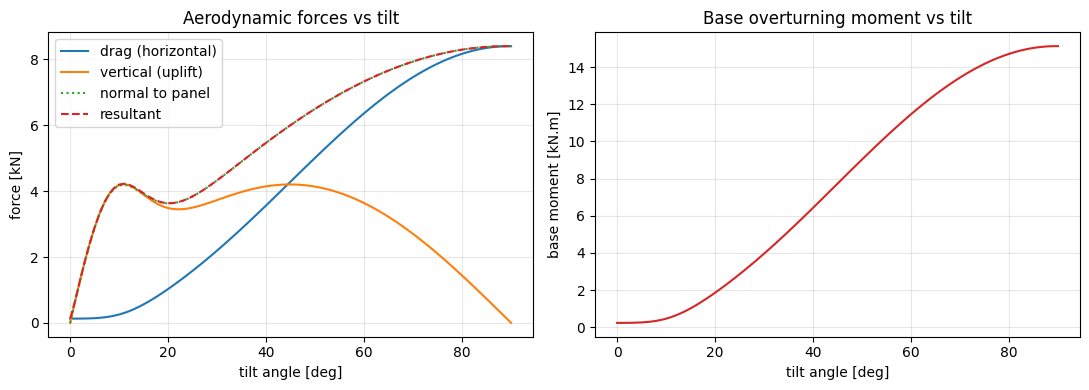

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(tilt, drag / 1e3, label="drag (horizontal)")
ax[0].plot(tilt, lift / 1e3, label="vertical (uplift)")
ax[0].plot(tilt, normal / 1e3, ":", label="normal to panel")
ax[0].plot(tilt, resultant / 1e3, "--", label="resultant")
ax[0].set_xlabel("tilt angle [deg]"); ax[0].set_ylabel("force [kN]")
ax[0].set_title("Aerodynamic forces vs tilt"); ax[0].legend(); ax[0].grid(alpha=.3)
 
ax[1].plot(tilt, base_moment / 1e3, color="C3")
ax[1].set_xlabel("tilt angle [deg]"); ax[1].set_ylabel("base moment [kN.m]")
ax[1].set_title("Base overturning moment vs tilt"); ax[1].grid(alpha=.3)
plt.tight_layout(); 
 
def report_optimum(name, curve, unit, scale):
    i_min = int(np.argmin(curve)); i_max = int(np.argmax(curve))
    print("%-22s  min %6.1f %s at %2.0f deg   |   max %6.1f %s at %2.0f deg"
          % (name, curve[i_min] / scale, unit, tilt[i_min],
             curve[i_max] / scale, unit, tilt[i_max]))
 
print("\n================  SOLAR PANEL LOAD SUMMARY  ================")
report_optimum("Drag (horizontal)",  drag,          "kN",   1e3)
report_optimum("Vertical (uplift)",  np.abs(lift),  "kN",   1e3)
report_optimum("Normal to panel",    normal,        "kN",   1e3)
report_optimum("Resultant force",    resultant,     "kN",   1e3)
report_optimum("Base moment",        base_moment,   "kN.m", 1e3)
print("-----------------------------------------------------------")
opt = int(np.argmin(resultant))
i_uplift = int(np.argmax(lift))
print("OPTIMUM STOW TILT (min resultant/drag): %.0f deg" % tilt[opt])
print("Largest uplift is at %.0f deg tilt -- note this is a LOW angle, driven"
      % tilt[i_uplift])
print("by the attached-flow lift peak just before stall.")
print("===========================================================")


# Extra: turbulence

The steady analysis (see `solar_panel_loads.py`) says a panel stowed **flat
(tilt = 0)** in a horizontal wind carries almost no normal load, because the
mean angle of attack is zero. Real storm wind is **turbulent**: it has a
vertical fluctuation $w(t)$, so the *instantaneous* angle of attack of a flat
panel is

$$\alpha(t)\approx \frac{w(t)}{U}\neq 0,$$

and a longitudinal fluctuation $u(t)$ that pumps the dynamic pressure. The
instantaneous force therefore fluctuates about zero with large peaks.


In [ ]:
# %%
# -------- INPUTS --------
U_MEAN = U_REF        # mean wind speed at panel height [m/s]
I_U    = 0.18        # longitudinal turbulence intensity sigma_u/U (~0.1-0.25 in storms)
R_V, R_W = 0.80, 0.50    # sigma_v/sigma_u, sigma_w/sigma_u
L_U, L_V, L_W = 100.0, 33.0, 8.0     # integral length scales [m]

DURATION = 600.0     # record length [s]  (10 min)
DT       = 0.1       # time step [s]  -> 5 Hz Nyquist, fine for panel loads

rng = np.random.default_rng(seed=1000)  # for reproducibility

sigma_u = I_U * U_MEAN
sigma_v = R_V * sigma_u
sigma_w = R_W * sigma_u
N = int(DURATION / DT)
t = np.arange(N) * DT

One-sided Kaimal power spectral density (integrates to $\sigma^2$):

$$S_K(f)=\frac{\sigma^2\,4L/U}{\left(1+6\,fL/U\right)^{5/3}}.$$

We build each component as a sum of harmonics with the Kaimal amplitudes and
**random phases** (the spectral representation method), then variance-match to
the exact target $\sigma$.

Target  sigma (u,v,w) = 7.44, 5.95, 3.72 m/s
Sampled sigma (u,v,w) = 7.44, 5.95, 3.72 m/s
Turbulence intensities: Iu=0.18  Iv=0.14  Iw=0.09
saved turb_fig1_timeseries.png


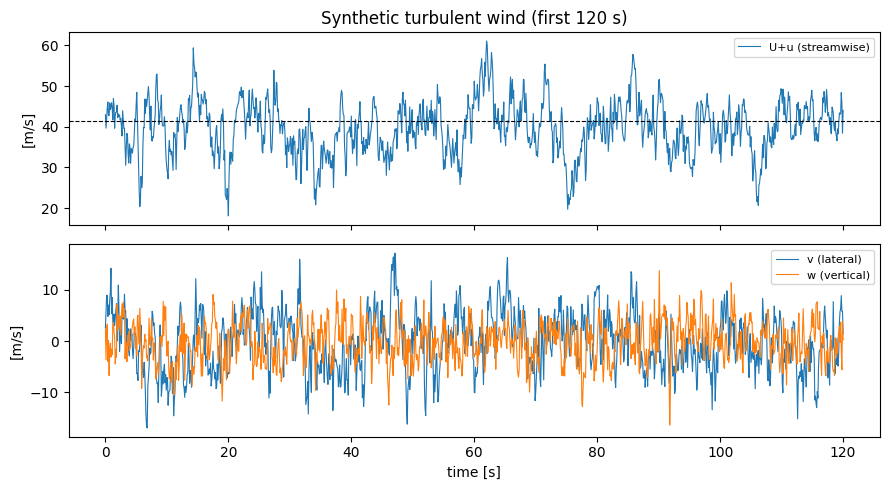

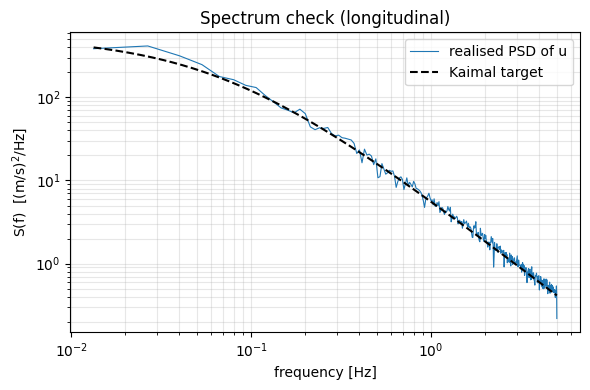

In [16]:

# %%
def kaimal_psd(f, sigma, L, U):
    """One-sided Kaimal PSD [ (m/s)^2 / Hz ]."""
    return sigma ** 2 * (4.0 * L / U) / (1.0 + 6.0 * f * L / U) ** (5.0 / 3.0)

def synth_component(sigma, L, U, N, dt, rng):
    """Gaussian turbulence sample with a Kaimal spectrum (random-phase method)."""
    freqs = np.fft.rfftfreq(N, dt)
    df = freqs[1] - freqs[0]
    S = np.where(freqs > 0, kaimal_psd(freqs, sigma, L, U), 0.0)
    phases = rng.uniform(0, 2 * np.pi, size=freqs.size)
    X = np.sqrt(S * df) * np.exp(1j * phases)
    X[0] = 0.0                                   # zero mean
    x = np.fft.irfft(X, n=N)
    x -= x.mean()
    x *= sigma / np.std(x)                        # match target variance exactly
    return x



u = synth_component(sigma_u, L_U, U_MEAN, N, DT, rng)
v = synth_component(sigma_v, L_V, U_MEAN, N, DT, rng)
w = synth_component(sigma_w, L_W, U_MEAN, N, DT, rng)

print("Target  sigma (u,v,w) = %.2f, %.2f, %.2f m/s" % (sigma_u, sigma_v, sigma_w))
print("Sampled sigma (u,v,w) = %.2f, %.2f, %.2f m/s" % (u.std(), v.std(), w.std()))
print("Turbulence intensities: Iu=%.2f  Iv=%.2f  Iw=%.2f"
      % (u.std() / U_MEAN, v.std() / U_MEAN, w.std() / U_MEAN))

# %%
def welch_psd(x, dt, nseg=8):
    """Simple one-sided Welch PSD estimate (Hann window, 50% overlap)."""
    N = len(x); seg = N // nseg; step = seg // 2
    win = np.hanning(seg); fs = 1.0 / dt
    norm = fs * np.sum(win ** 2)
    freqs = np.fft.rfftfreq(seg, dt)
    acc = np.zeros(freqs.size); k = 0
    start = 0
    while start + seg <= N:
        xs = (x[start:start + seg] - x[start:start + seg].mean()) * win
        P = np.abs(np.fft.rfft(xs)) ** 2 / norm
        P[1:-1] *= 2.0
        acc += P; k += 1; start += step
    return freqs, acc / max(k, 1)

# window of the time series (first 120 s) for readability
m = t <= 120
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(t[m], U_MEAN + u[m], lw=.8, label="U+u (streamwise)")
ax[0].axhline(U_MEAN, color="k", lw=.8, ls="--")
ax[0].set_ylabel("[m/s]"); ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t[m], v[m], lw=.8, label="v (lateral)")
ax[1].plot(t[m], w[m], lw=.8, label="w (vertical)")
ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("[m/s]")
ax[1].legend(loc="upper right", fontsize=8)
ax[0].set_title("Synthetic turbulent wind (first 120 s)")
plt.tight_layout(); plt.savefig("turb_fig1_timeseries.png", dpi=120)
print("saved turb_fig1_timeseries.png")

f_est, P_est = welch_psd(u, DT)
plt.figure(figsize=(6, 4))
plt.loglog(f_est[1:], P_est[1:], lw=.8, label="realised PSD of u")
ff = np.logspace(np.log10(f_est[1]), np.log10(f_est[-1]), 200)
plt.loglog(ff, kaimal_psd(ff, sigma_u, L_U, U_MEAN), "k--", label="Kaimal target")
plt.xlabel("frequency [Hz]"); plt.ylabel("S(f)  [(m/s)$^2$/Hz]")
plt.title("Spectrum check (longitudinal)"); plt.legend(); plt.grid(alpha=.3, which="both")
plt.tight_layout(); 



Instantaneous force on a panel at tilt $\beta$

The instantaneous wind vector is $\mathbf V=(U+u,\;v,\;w)$. For a panel tilted
$\beta$ about the cross-wind axis the outward normal is
$\mathbf n=(\sin\beta,\,0,\,\cos\beta)$. The instantaneous angle of attack (the
angle between the flow and the panel surface) is

$$\alpha(t)=\arcsin\!\frac{\mathbf V\cdot\mathbf n}{|\mathbf V|}
            =\arcsin\!\frac{(U+u)\sin\beta+w\cos\beta}{|\mathbf V|}.$$

The force normal to the panel is $F_N=\tfrac12\rho|\mathbf V|^2 A\,C_N(\alpha)$,
and its **vertical (uplift)** component is $F_N\cos\beta$. Note at $\beta=0$:
$\alpha(t)=\arcsin(w/|\mathbf V|)\approx w/U$ — set purely by the vertical gust.


--- Panel stowed FLAT (tilt = 0) ---
Steady (mean-wind) normal force    :   0.00 kN
Turbulent instantaneous normal force:
   mean   :   0.00 kN
   std    :   3.89 kN
   min/max: -10.78 /  11.92 kN
   peak factor (max-mean)/std : 3.1
   instantaneous |alpha| reaches 28 deg from w-gusts alone


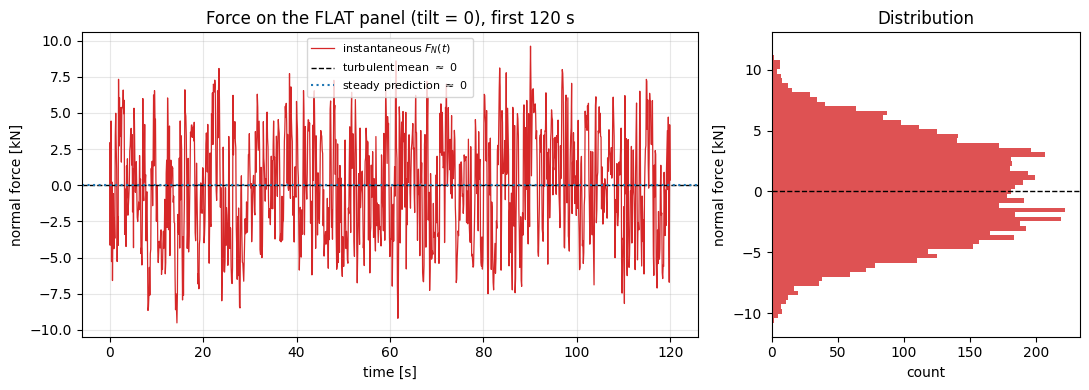

In [18]:
# %%
def flat_plate_cn(alpha_deg, cn_max=1.3, alpha_sep_deg=10.0,
                  sep_width_deg=4.0, cl_slope=2 * np.pi, cd_fric=0.02):
    """Signed normal-force coefficient of a flat plate, incl. leading-edge
    separation. Odd in alpha: Cn(-a) = -Cn(a)."""
    a_deg = np.asarray(alpha_deg, float)
    sgn = np.sign(a_deg); ad = np.abs(a_deg); a = np.radians(ad)
    sigma = 1.0 / (1.0 + np.exp(-(ad - alpha_sep_deg) / sep_width_deg))
    cl_att = cl_slope * np.sin(a) * np.cos(a)
    cn_sep = cn_max * np.sin(a)
    cl_sep = cn_sep * np.cos(a)
    cd_sep = cn_sep * np.sin(a) + cd_fric * np.cos(a)
    cl = (1 - sigma) * cl_att + sigma * cl_sep
    cd = (1 - sigma) * cd_fric + sigma * cd_sep
    cn = cl * np.cos(a) + cd * np.sin(a)          # magnitude, normal to plate
    return sgn * cn

# %%
PANEL_AREA = 9.2      # m^2  (matches the steady notebook: 2.3 m x 4.0 m)

def panel_force(beta_deg):
    """Return dict of instantaneous alpha, normal force and uplift time series."""
    b = np.radians(beta_deg)
    Vx = U_MEAN + u
    Vmag = np.sqrt(Vx ** 2 + v ** 2 + w ** 2)
    Vn = Vx * np.sin(b) + w * np.cos(b)
    alpha = np.degrees(np.arcsin(np.clip(Vn / Vmag, -1, 1)))
    q = 0.5 * RHO_AIR * Vmag ** 2
    Fn = q * PANEL_AREA * flat_plate_cn(alpha)          # normal to panel [N]
    uplift = Fn * np.cos(b)                             # vertical component [N]
    return dict(alpha=alpha, Fn=Fn, uplift=uplift)


# ---- focus case: FLAT stow, tilt = 0 ----
flat = panel_force(0.0)
Fn0 = flat["Fn"]

# steady (mean-wind) prediction at tilt 0 is essentially zero:
F_steady_0 = 0.5 * RHO_AIR * U_MEAN ** 2 * PANEL_AREA * flat_plate_cn(0.0)

print("\n--- Panel stowed FLAT (tilt = 0) ---")
print("Steady (mean-wind) normal force    : %6.2f kN" % (F_steady_0 / 1e3))
print("Turbulent instantaneous normal force:")
print("   mean   : %6.2f kN" % (Fn0.mean() / 1e3))
print("   std    : %6.2f kN" % (Fn0.std() / 1e3))
print("   min/max: %6.2f / %6.2f kN" % (Fn0.min() / 1e3, Fn0.max() / 1e3))
print("   peak factor (max-mean)/std : %.1f" % ((Fn0.max() - Fn0.mean()) / Fn0.std()))
print("   instantaneous |alpha| reaches %.0f deg from w-gusts alone"
      % np.abs(flat["alpha"]).max())

# %%
fig, ax = plt.subplots(1, 2, figsize=(11, 4),
                       gridspec_kw={"width_ratios": [2, 1]})
mm = t <= 120
ax[0].plot(t[mm], Fn0[mm] / 1e3, lw=.9, color="C3", label="instantaneous $F_N(t)$")
ax[0].axhline(Fn0.mean() / 1e3, color="k", ls="--", lw=1, label="turbulent mean $\\approx$ 0")
ax[0].axhline(F_steady_0 / 1e3, color="C0", ls=":", lw=1.5, label="steady prediction $\\approx$ 0")
ax[0].set_xlabel("time [s]"); ax[0].set_ylabel("normal force [kN]")
ax[0].set_title("Force on the FLAT panel (tilt = 0), first 120 s")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].hist(Fn0 / 1e3, bins=60, orientation="horizontal", color="C3", alpha=.8)
ax[1].axhline(0, color="k", ls="--", lw=1)
ax[1].set_xlabel("count"); ax[1].set_ylabel("normal force [kN]")
ax[1].set_title("Distribution")
plt.tight_layout();


The steady load is the *mean*; design has to survive the *peaks*. The gap is
largest exactly where the steady model says "safe" — at tilt = 0.

In [19]:
print("\n tilt |  mean F_N | std F_N | peak |F_N| | peak/|mean|")
print("------+-----------+---------+-----------+------------")
for beta in [0, 10, 20, 30, 45, 60]:
    r = panel_force(beta)["Fn"]
    peak = np.abs(r).max()
    ratio = peak / max(abs(r.mean()), 1e-9)
    print(" %4d | %7.2f kN | %5.2f kN | %7.2f kN | %8s"
          % (beta, r.mean() / 1e3, r.std() / 1e3, peak / 1e3,
             ("%.1fx" % ratio) if abs(r.mean()) > 50 else "inf"))



 tilt |  mean F_N | std F_N | peak |F_N| | peak/|mean|
------+-----------+---------+-----------+------------
    0 |    0.00 kN |  3.89 kN |   11.92 kN |      inf
   10 |    5.43 kN |  2.69 kN |   13.98 kN |     2.6x
   20 |    5.89 kN |  2.00 kN |   13.32 kN |     2.3x
   30 |    6.73 kN |  2.39 kN |   15.86 kN |     2.4x
   45 |    9.17 kN |  3.25 kN |   20.87 kN |     2.3x
   60 |   11.19 kN |  3.89 kN |   25.13 kN |     2.2x


In [20]:

# * At **tilt = 0** the steady and mean turbulent normal forces are ~0, yet the
#   instantaneous force swings by several kN and **peaks at 10-15+ kN** — vertical
#   gusts $w(t)$ create real, alternating angles of attack, and streamwise gusts
#   $u(t)$ raise the dynamic pressure at the same time. A "safely stowed" flat
#   panel is not unloaded; it is *cyclically* loaded, which also matters for
#   fatigue and connection design.
# * The **peak-to-mean ratio blows up as tilt -> 0** (the mean goes to zero but
#   the peak does not), which is why wind codes work with peak/gust pressures and
#   gust factors rather than mean loads.
#
# Caveats:
#  * **Quasi-steady** aerodynamics assumed (the plate reacts instantly). Real
#    unsteady effects (added mass, dynamic stall, wake lag) modify the peaks.
#  * The gust is treated as **uniform over the panel**. Because eddies comparable
#    to or smaller than the panel are partly averaged out (aerodynamic
#    admittance < 1 at high frequency), a point model *overstates* the
#    highest-frequency fluctuations — try low-pass filtering $u,v,w$ at
#    $f\sim U/\text{chord}$ to mimic this.